# 🧠 MedAssist-AI — Deep Learning para Clasificación de Medicamentos
## Notebook 2 de 3: CNN desde cero y Transfer Learning

**Objetivo**: clasificar imágenes de cajas y pastillas en 5 macroclases terapéuticas usando redes neuronales convolucionales.

**Contexto**: el notebook anterior (ML clásico) estableció un baseline con HOG + LBP + SVM. Este notebook busca superarlo aprendiendo representaciones automáticamente. Usamos el **mismo split** del EDA para que la comparación sea justa.

---

### Estructura del notebook

| Bloque | Contenido |
|--------|-----------|
| **0** | Configuración, imports, reproducibilidad |
| **1** | Dataset, DataLoaders y augmentation online |
| **2** | CNN From Scratch — arquitectura y entrenamiento |
| **3** | Transfer Learning — EfficientNet-B0 y ResNet50 |
| **4** | Comparativa completa (Scratch vs TL vs ML) |
| **5** | Grad-CAM — interpretabilidad visual |
| **6** | Evaluación final en test y exportación del modelo |

---

---
# BLOQUE 0 — Configuración

In [1]:
import warnings, random, os, time, json
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import (
    resnet50,        ResNet50_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import matplotlib.cm as mplcm
import seaborn as sns
import joblib

# ─────────────────────────────────────────────────────────────────────────────
SEED        = 42
IMG_SIZE    = 224
BATCH       = 32
PATIENCE    = 6
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Rutas ─────────────────────────────────────────────────────────────────────
# IMAGES_DIR: carpeta donde están las imágenes en ESTA máquina.
# - Misma máquina que el EDA  → None  (las rutas del CSV son válidas)
# - Lightning AI              → Path('/teamspace/studios/this_studio/imagenes')
# - Google Colab              → Path('/content/drive/MyDrive/med_images')
# - Kaggle                    → Path('/kaggle/input/med-images')
IMAGES_DIR   = Path('/teamspace/studios/this_studio/imagenes')  # ← CAMBIAR si procede

CSV_BALANCED = 'output/dataset_balanced.csv'
CSV_ORIGINAL = 'output/dataset_split.csv'
OUTPUT_DIR   = Path('output_dl')
OUTPUT_DIR.mkdir(exist_ok=True)

CLASES  = ['Cardiovascular','Neurología y psiquiatría','Antiinfecciosos sistémicos','Respiratorio','otros']
PALETTE = dict(zip(CLASES, ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']))
N_CLS   = len(CLASES)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})
sns.set_style('whitegrid')

print(f'✔ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU:  {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  Sin GPU — usa Colab (Runtime → Change runtime type → T4 GPU)')
print(f'✔ Clases: {N_CLS}  |  Seed: {SEED}  |  Batch: {BATCH}')


✔ Device: cuda
  GPU:  Tesla T4
  VRAM: 15.6 GB
✔ Clases: 5  |  Seed: 42  |  Batch: 32


### 💡 Sobre el entorno de ejecución

En CPU el entrenamiento de una red preentrenada con fine-tuning (~5K imágenes, 20 épocas) tarda **60–120 minutos**. Si no tienes GPU local, usa Google Colab o Kaggle (ambos con GPU gratuita).

El parámetro `torch.backends.cudnn.deterministic = True` garantiza resultados reproducibles en GPU a costa de un ~5% de velocidad. Precio correcto para resultados comparables entre ejecuciones.


---
# BLOQUE 1 — Dataset y DataLoaders

## 1. Carga del CSV y remapping de rutas

Usamos el **mismo `dataset_balanced.csv`** generado en el EDA. Esto garantiza el mismo split train/val/test que el notebook de ML → comparación justa.

**Nota sobre el augmentation**: en DL usamos solo las imágenes **originales** de train (`augmented == False`). El augmentation se aplicará online en cada epoch a través del DataLoader, dando variedad infinita en lugar de un conjunto fijo de imágenes sintéticas.


In [2]:
# Cargar CSV
if Path(CSV_BALANCED).exists():
    df = pd.read_csv(CSV_BALANCED, dtype={'nregistro': str})
    print(f'✔ Cargado: {CSV_BALANCED}')
elif Path(CSV_ORIGINAL).exists():
    df = pd.read_csv(CSV_ORIGINAL, dtype={'nregistro': str})
    df['augmented'] = False
    print(f'✔ Fallback: {CSV_ORIGINAL}')
else:
    raise FileNotFoundError(
        'CSV no encontrado. Ejecuta primero el notebook de EDA.\n'
        f'Buscado en: {Path(CSV_BALANCED).resolve()}'
    )

df = df[df['clase'].notna() & df['image_path'].notna()].copy().reset_index(drop=True)

# ── Remap de rutas (si ejecutamos en otra máquina) ────────────────────────────
if IMAGES_DIR is not None:
    IMAGES_DIR = Path(IMAGES_DIR)
    if not IMAGES_DIR.exists():
        raise FileNotFoundError(f'IMAGES_DIR no existe: {IMAGES_DIR}')

    n_check = min(30, len(df))
    n_ok    = df['image_path'].head(n_check).apply(lambda p: Path(p).exists()).sum()

    if n_ok < n_check:
        print(f'  Rutas del CSV no válidas aquí ({n_ok}/{n_check}). Reconstruyendo índice...')
        ext = {'.jpg','.jpeg','.png','.webp','.bmp'}
        idx = {p.name: str(p) for p in IMAGES_DIR.rglob('*') if p.suffix.lower() in ext}
        print(f'  {len(idx):,} imágenes indexadas en {IMAGES_DIR}')
        df['image_path'] = df['image_path'].map(lambda p: idx.get(Path(p).name, p))
        n_ok2 = df['image_path'].apply(lambda p: Path(p).exists()).sum()
        print(f'  ✔ Remap: {n_ok2:,}/{len(df):,} rutas válidas')
    else:
        print('  ✔ Rutas ya válidas — sin remap necesario')
else:
    n_ok = df['image_path'].head(30).apply(lambda p: Path(p).exists()).sum()
    if n_ok == 0:
        raise RuntimeError(
            'Ninguna ruta de imagen válida con IMAGES_DIR=None.\n'
            f'Ejemplo ruta del CSV: {df["image_path"].iloc[0]}\n'
            'Configura IMAGES_DIR con la ruta correcta.'
        )

# Splits — solo imágenes originales en train
df_train = df[(df['split']=='train') & (df['augmented']==False)].reset_index(drop=True)
df_val   = df[df['split']=='val'].reset_index(drop=True)
df_test  = df[df['split']=='test'].reset_index(drop=True)

le = LabelEncoder()
le.fit(CLASES)

print(f'\n  Train (originales): {len(df_train):,}')
print(f'  Val:                {len(df_val):,}')
print(f'  Test:               {len(df_test):,}')
print(f'  Medicamentos únicos: {df["nregistro"].nunique():,}')
print()
print('  Distribución clases TRAIN:')
for cls, cnt in df_train['clase'].value_counts().reindex(CLASES).items():
    bar = '█' * (cnt // max(1, df_train['clase'].value_counts().max() // 25))
    print(f'    {cls:<35} {cnt:>5}  {bar}')


✔ Cargado: output/dataset_balanced.csv
  Rutas del CSV no válidas aquí (0/30). Reconstruyendo índice...
  10,000 imágenes indexadas en /teamspace/studios/this_studio/imagenes
  ✔ Remap: 9,998/20,486 rutas válidas

  Train (originales): 6,999
  Val:                1,500
  Test:               1,499
  Medicamentos únicos: 5,021

  Distribución clases TRAIN:
    Cardiovascular                       1264  █████████
    Neurología y psiquiatría             1122  ████████
    Antiinfecciosos sistémicos            564  ████
    Respiratorio                          535  ███
    otros                                3514  █████████████████████████


## 2. Clase Dataset y transformaciones

### ¿Por qué transformaciones distintas para train y val/test?

En **train** aplicamos augmentation aleatorio: flips, rotaciones pequeñas, cambios de brillo. Cada época, la misma imagen aparece transformada de forma distinta → el modelo ve más variedad sin necesitar más datos reales.

En **val/test** las transformaciones son **deterministas** (solo resize + normalización). Si aplicáramos augmentation en validación, los resultados variarían entre ejecuciones y no podríamos comparar modelos de forma reproducible.

La normalización ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) es **obligatoria** para transfer learning. Los pesos preentrenados esperan exactamente esta distribución de entrada.


In [3]:
class MedDataset(Dataset):
    def __init__(self, df, transform, label_encoder):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.le        = label_encoder
        # Filtrar imágenes inexistentes
        valid = self.df['image_path'].apply(lambda p: Path(p).exists())
        n_missing = (~valid).sum()
        if n_missing > 0:
            print(f'  ⚠  {n_missing} imágenes no encontradas → se descartan')
        self.df = self.df[valid].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(self.le.transform([row['clase']])[0])
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))
        return self.transform(img), label


transform_train = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=12),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.04),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

dataset_train = MedDataset(df_train, transform_train, le)
dataset_val   = MedDataset(df_val,   transform_eval,  le)
dataset_test  = MedDataset(df_test,  transform_eval,  le)

print(f'✔ Datasets creados:')
print(f'  Train: {len(dataset_train):,} imágenes')
print(f'  Val:   {len(dataset_val):,} imágenes')
print(f'  Test:  {len(dataset_test):,} imágenes')


✔ Datasets creados:
  Train: 6,999 imágenes
  Val:   1,500 imágenes
  Test:  1,499 imágenes


## 3. DataLoaders con muestreo balanceado

Usamos `WeightedRandomSampler` en train para que cada batch tenga una distribución uniforme de clases, independientemente del desbalance real del dataset.

**¿Por qué no usar también pesos en la función de pérdida?**
Son dos formas de hacer lo mismo. Combinarlas (doble ponderación) produce gradientes inestables y puede llevar a accuracy ≈ 0. Elegimos el sampler porque actúa a nivel de datos, no de optimización.


In [4]:
N_WORKERS = min(4, os.cpu_count() or 1)

# WeightedRandomSampler: muestrea con probabilidad inversamente proporcional al tamaño de clase
lbl_train    = np.array(le.transform(dataset_train.df['clase'].values))
counts       = np.bincount(lbl_train, minlength=N_CLS)
weights_cls  = 1.0 / (counts + 1)              # sumar 1 evita división por cero
weights_samp = torch.tensor(weights_cls[lbl_train], dtype=torch.float)
sampler      = WeightedRandomSampler(weights_samp, len(weights_samp), replacement=True)

dl_train = DataLoader(dataset_train, batch_size=BATCH, sampler=sampler,
                      num_workers=N_WORKERS, pin_memory=(DEVICE.type=='cuda'), drop_last=True)
dl_val   = DataLoader(dataset_val,   batch_size=BATCH, shuffle=False,
                      num_workers=N_WORKERS, pin_memory=(DEVICE.type=='cuda'))
dl_test  = DataLoader(dataset_test,  batch_size=BATCH, shuffle=False,
                      num_workers=N_WORKERS, pin_memory=(DEVICE.type=='cuda'))

print(f'✔ DataLoaders:  Train {len(dl_train)} batches | Val {len(dl_val)} | Test {len(dl_test)}')
print()
print('  Distribución esperada por clase (balanceada por sampler):')
for i, (cls, cnt) in enumerate(zip(CLASES, counts)):
    w = weights_cls[i] / weights_cls.sum()
    print(f'    {cls:<35} n={cnt:>5}  peso muestreo={w:.3f}')


✔ DataLoaders:  Train 218 batches | Val 47 | Test 47

  Distribución esperada por clase (balanceada por sampler):
    Cardiovascular                      n=  564  peso muestreo=0.316
    Neurología y psiquiatría            n= 1264  peso muestreo=0.141
    Antiinfecciosos sistémicos          n= 1122  peso muestreo=0.159
    Respiratorio                        n=  535  peso muestreo=0.333
    otros                               n= 3514  peso muestreo=0.051


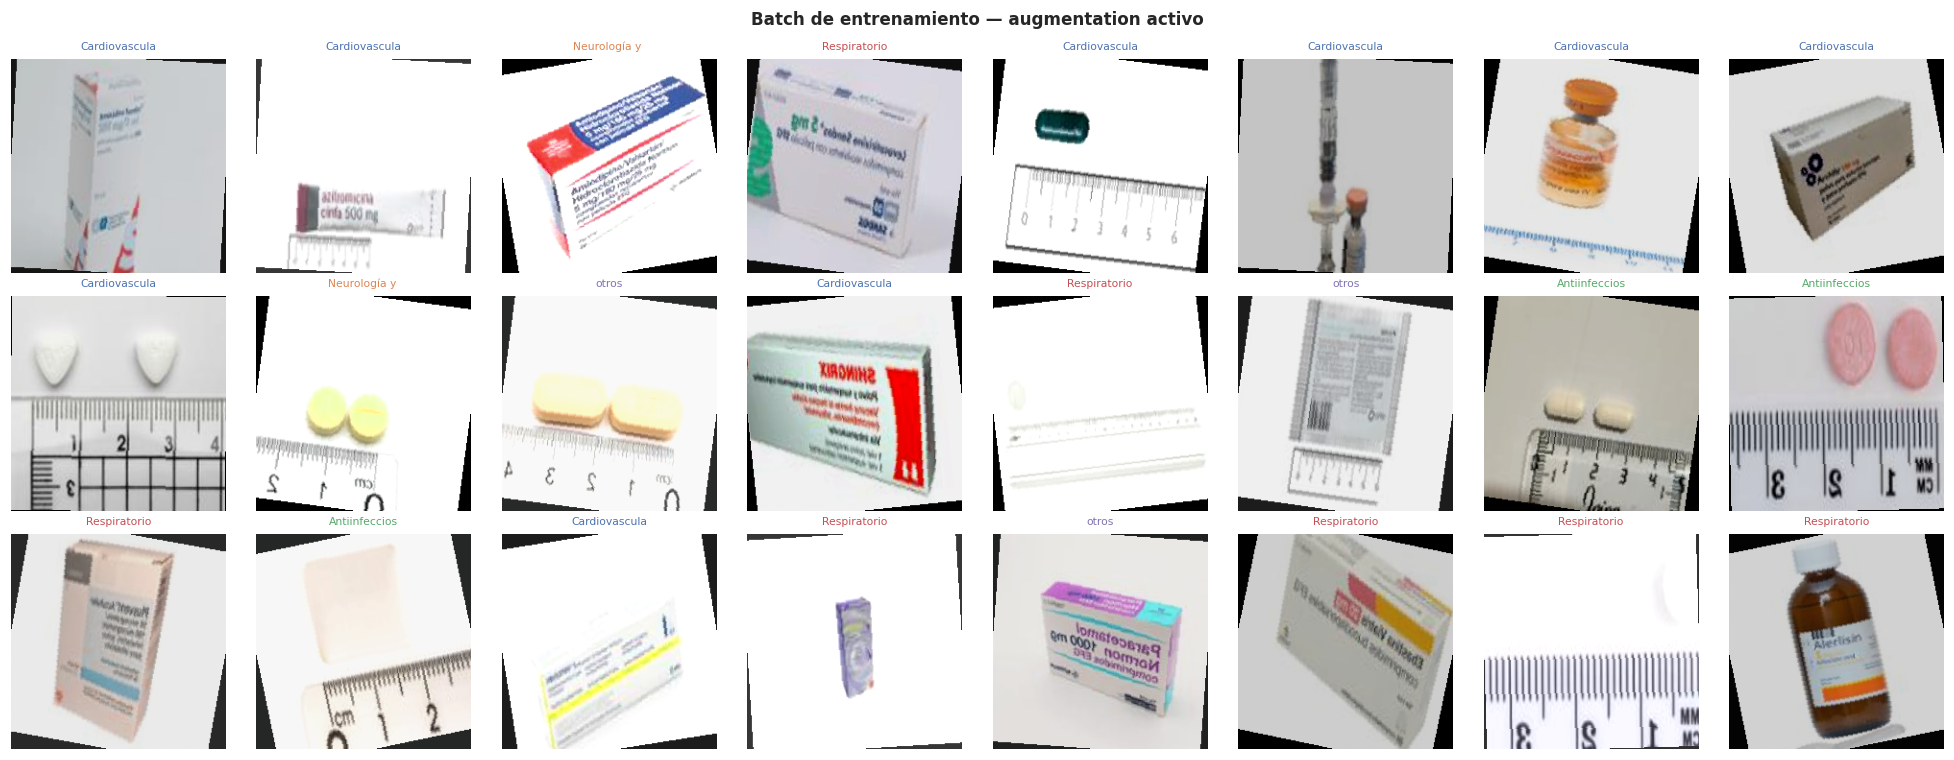

✔ Las imágenes cargan correctamente con augmentation
  Tensor shape: torch.Size([32, 3, 224, 224])  |  min: -2.12  max: 2.64


In [5]:
# Verificar que las imágenes cargan correctamente
def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    s = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t * s + m).clamp(0, 1)

imgs, labels = next(iter(dl_train))
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
for ax, img, lbl in zip(axes.flatten(), imgs[:24], labels[:24]):
    ax.imshow(denorm(img).permute(1,2,0).numpy())
    ax.set_title(CLASES[lbl][:13], fontsize=7, color=list(PALETTE.values())[lbl])
    ax.axis('off')
plt.suptitle('Batch de entrenamiento — augmentation activo', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dl_batch_sample.png', bbox_inches='tight')
plt.show()
print('✔ Las imágenes cargan correctamente con augmentation')
print(f'  Tensor shape: {imgs.shape}  |  min: {imgs.min():.2f}  max: {imgs.max():.2f}')


### 💡 Conclusión — DataLoaders

Si la celda anterior muestra imágenes grises o negras, **hay un problema con las rutas**. Configura `IMAGES_DIR` en la celda de configuración y vuelve a ejecutar desde la celda de carga del CSV.

Si las imágenes cargan bien, debería verse:
- Cajas de medicamentos con colores, texto y bordes visibles
- Ligeras variaciones de brillo/contraste entre imágenes (augmentation activo)
- Distribución razonablemente uniforme de colores de título entre las clases


---
# BLOQUE 2 — CNN From Scratch

## 4. Arquitectura MedCNN

Diseñamos una CNN propia antes de usar modelos preentrenados. Su objetivo no es ganar al estado del arte, sino responder a una pregunta metodológica: **¿cuánto rinde una red sin conocimiento previo de ImageNet, pero con un diseño razonable?**

### Arquitectura: 4 bloques Conv-BN-ReLU-Pool

```
Input (3 × 224 × 224)
  → Bloque 1: Conv(3→32)×2   + BatchNorm + MaxPool  → 32 × 112 × 112
  → Bloque 2: Conv(32→64)×2  + BatchNorm + MaxPool  → 64 × 56 × 56
  → Bloque 3: Conv(64→128)×2 + BatchNorm + MaxPool  → 128 × 28 × 28
  → Bloque 4: Conv(128→256)  + BatchNorm + MaxPool  → 256 × 14 × 14
  → AdaptiveAvgPool(1)  → 256 × 1 × 1
  → FC: 256 → 128 → 5  (con Dropout)
```

**BatchNorm** después de cada convolución estabiliza el entrenamiento y actúa como regularizador suave. **AdaptiveAvgPool** permite usar la misma arquitectura con cualquier tamaño de entrada.


In [6]:
class MedCNN(nn.Module):
    """CNN from scratch para clasificación de imágenes farmacéuticas."""
    def __init__(self, n_classes=N_CLS, dropout=0.45):
        super().__init__()

        def bloque(cin, cout, n_conv=2):
            layers = []
            for i in range(n_conv):
                layers += [
                    nn.Conv2d(cin if i == 0 else cout, cout, 3, padding=1, bias=False),
                    nn.BatchNorm2d(cout),
                    nn.ReLU(inplace=True),
                ]
            layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            bloque(3,   32,  n_conv=2),   # → 32×112×112
            bloque(32,  64,  n_conv=2),   # → 64×56×56
            bloque(64,  128, n_conv=2),   # → 128×28×28
            bloque(128, 256, n_conv=1),   # → 256×14×14
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))


# Verificar dimensiones con un forward pass en frío
model_cnn = MedCNN().to(DEVICE)
with torch.no_grad():
    x_dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    feats   = model_cnn.features(x_dummy)
    out     = model_cnn(x_dummy)

n_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f'MedCNN — parámetros: {n_params:,}')
print(f'  Features output: {tuple(feats.shape)}')
print(f'  Logits output:   {tuple(out.shape)}  (batch=2, clases={N_CLS})')


MedCNN — parámetros: 616,421
  Features output: (2, 256, 14, 14)
  Logits output:   (2, 5)  (batch=2, clases=5)


## 5. Funciones de entrenamiento (únicas para todo el notebook)

Una sola pareja `train_epoch` / `eval_epoch` sirve tanto para la CNN scratch como para el transfer learning. La única diferencia entre ambos escenarios está en el modelo y el optimizador que se les pasa — no en el bucle de entrenamiento.


In [7]:
def train_epoch(model, loader, criterion, optimizer):
    """Una época de entrenamiento. Devuelve (loss_medio, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    """Evaluación sin gradientes. Devuelve (loss, accuracy, f1_macro, preds, labels)."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits       = model(imgs)
        total_loss  += criterion(logits, labels).item() * len(labels)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    n   = len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / n, acc, f1, np.array(all_preds), np.array(all_labels)


def run_training(model, model_name, n_epochs, optimizer, scheduler,
                 patience=PATIENCE, criterion=None):
    """
    Bucle completo con early stopping sobre Val F1-macro.
    Devuelve historial de métricas y restaura los mejores pesos.
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    hist = {k: [] for k in ['tr_loss','val_loss','tr_acc','val_acc','val_f1','lr']}
    best_f1, best_w, no_improve = 0.0, None, 0

    print(f'\n{"═"*65}')
    print(f'  {model_name}')
    print(f'{"═"*65}')
    print(f'  {"Ép":>3}  {"LR":>9}  {"Tr Loss":>8}  {"Tr Acc":>7}  '
          f'{"Val Loss":>8}  {"Val Acc":>7}  {"Val F1":>7}')
    print(f'  {"─"*62}')

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc               = train_epoch(model, dl_train, criterion, optimizer)
        val_loss, val_acc, val_f1, _, _ = eval_epoch(model, dl_val, criterion)
        lr_now = optimizer.param_groups[0]['lr']

        if scheduler is not None:
            try:    scheduler.step(val_loss)
            except: scheduler.step()

        hist['tr_loss'].append(tr_loss);  hist['val_loss'].append(val_loss)
        hist['tr_acc'].append(tr_acc);    hist['val_acc'].append(val_acc)
        hist['val_f1'].append(val_f1);    hist['lr'].append(lr_now)

        mark = ''
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_w  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0; mark = ' ★'
        else:
            no_improve += 1

        if ep == 1 or ep % 5 == 0 or mark or no_improve >= patience:
            elapsed = time.time() - t0
            print(f'  {ep:>3}  {lr_now:>9.2e}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  '
                  f'{val_loss:>8.4f}  {val_acc:>7.4f}  {val_f1:>7.4f}{mark}  '
                  f'({elapsed:.0f}s)')

        if no_improve >= patience:
            print(f'  Early stopping en época {ep}.')
            break

    model.load_state_dict(best_w)
    model.to(DEVICE)
    print(f'  ✔ Mejor Val F1-macro: {best_f1:.4f}')
    return hist


def plot_curves(hist, title, save_name):
    """Curvas de accuracy, loss y F1-macro."""
    ep = range(1, len(hist['tr_loss']) + 1)
    gap = max(hist['tr_acc']) - max(hist['val_acc'])
    overfit = f'⚠ gap={gap:.3f}' if gap > 0.08 else f'✔ gap={gap:.3f}'

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(ep, hist['tr_acc'],  lw=2, label='Train', color='#4C72B0')
    axes[0].plot(ep, hist['val_acc'], lw=2, label='Val',   color='#DD8452', ls='--')
    axes[0].axhline(max(hist['val_acc']), color='green', ls=':', lw=1,
                    label=f'Best val={max(hist["val_acc"]):.3f}')
    axes[0].set_title(f'Accuracy  {overfit}', fontsize=9, fontweight='bold')
    axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8); axes[0].set_xlabel('Época')

    axes[1].plot(ep, hist['tr_loss'],  lw=2, label='Train', color='#4C72B0')
    axes[1].plot(ep, hist['val_loss'], lw=2, label='Val',   color='#DD8452', ls='--')
    axes[1].set_title('Cross-Entropy Loss', fontweight='bold')
    axes[1].legend(fontsize=8); axes[1].set_xlabel('Época')

    axes[2].plot(ep, hist['val_f1'], lw=2, color='#55A868', label='Val F1-macro')
    axes[2].axhline(max(hist['val_f1']), color='#55A868', ls=':', lw=1,
                    label=f'Best={max(hist["val_f1"]):.3f}')
    axes[2].set_title('Val F1-macro', fontweight='bold')
    axes[2].set_ylim(0, 1); axes[2].legend(fontsize=8); axes[2].set_xlabel('Época')

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'curves_{save_name}.png', bbox_inches='tight')
    plt.show()
    print(f'  Train acc: {hist["tr_acc"][-1]:.4f}  |  Val acc: {hist["val_acc"][-1]:.4f}'
          f'  |  Best val F1: {max(hist["val_f1"]):.4f}')


## 6. Entrenamiento CNN From Scratch

Entrenamos la MedCNN con Adam + ReduceLROnPlateau. Esperamos una accuracy de val en torno al **30–50%** en este problema de 5 clases (frente al 20% de un clasificador aleatorio).

El objetivo no es maximizar el rendimiento, sino establecer un punto de referencia honesto que justifique el uso de transfer learning.



═════════════════════════════════════════════════════════════════
  CNN From Scratch
═════════════════════════════════════════════════════════════════
   Ép         LR   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────────
    1   5.00e-04    1.5468   0.2996    1.6178   0.1813   0.1533 ★  (48s)
    2   5.00e-04    1.5373   0.3118    1.5826   0.1747   0.1938 ★  (38s)
    4   5.00e-04    1.5239   0.3248    1.5763   0.1967   0.2156 ★  (36s)
    5   5.00e-04    1.5137   0.3324    1.5997   0.1573   0.1822  (35s)
    7   2.50e-04    1.4947   0.3455    1.5303   0.2033   0.2260 ★  (35s)
    8   2.50e-04    1.4915   0.3506    1.5570   0.2247   0.2331 ★  (36s)
   10   2.50e-04    1.4678   0.3713    1.5698   0.2093   0.2251  (35s)
   13   1.25e-04    1.4620   0.3789    1.5317   0.2360   0.2380 ★  (37s)
   15   1.25e-04    1.4526   0.3850    1.5238   0.2320   0.2403 ★  (36s)
   17   6.25e-05    1.4279   0.3954    1.5187   0.2473   0.2471 ★ 

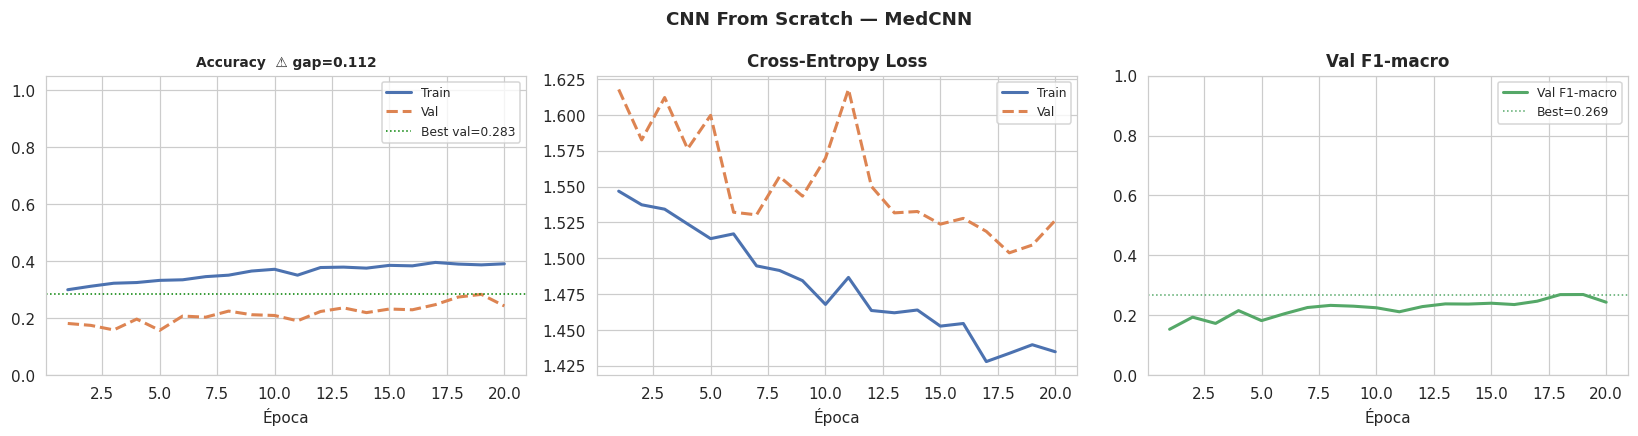

  Train acc: 0.3905  |  Val acc: 0.2427  |  Best val F1: 0.2694

CNN Scratch → Val Accuracy: 0.2833  |  Val F1-macro: 0.2694


In [9]:
N_EPOCHS_SCRATCH = 20

criterion_scratch = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer_scratch = optim.Adam(model_cnn.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler_scratch = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_scratch, mode='max', patience=4, factor=0.5, min_lr=1e-6)

hist_cnn = run_training(
    model_cnn, 'CNN From Scratch',
    n_epochs=N_EPOCHS_SCRATCH,
    optimizer=optimizer_scratch,
    scheduler=scheduler_scratch,
    criterion=criterion_scratch,
)

plot_curves(hist_cnn, 'CNN From Scratch — MedCNN', 'cnn_scratch')
_, acc_cnn, f1_cnn, _, _ = eval_epoch(model_cnn, dl_val, criterion_scratch)
print(f'\nCNN Scratch → Val Accuracy: {acc_cnn:.4f}  |  Val F1-macro: {f1_cnn:.4f}')


### 💡 Conclusión — CNN From Scratch

**Qué buscar en las curvas:**

| Patrón | Diagnóstico |
|--------|------------|
| train acc sube, val acc se estanca | Overfitting — falta de datos o regularización insuficiente |
| Ambas curvas suben lentamente | Normal en scratch, el modelo aprende desde cero |
| val_f1 oscila mucho | Batches demasiado pequeños o LR muy alto |
| Accuracy ≤ 0.20 tras 10 épocas | Problema de carga de imágenes — verificar IMAGES_DIR |

**¿Por qué la CNN scratch es limitada en este problema?**

Las imágenes de medicamentos son complejas: texto, logos, colores corporativos, diferentes formas y ángulos. Aprender representaciones de bajo nivel (bordes, texturas) desde cero requiere cientos de miles de imágenes. Con un dataset de tamaño moderado, la red no converge a representaciones suficientemente discriminativas.

Esto es exactamente el problema que resuelve el transfer learning.


---
# BLOQUE 3 — Transfer Learning

## 7. ¿Por qué funciona el transfer learning?

Una ResNet50 preentrenada en ImageNet ha visto 1.2 millones de imágenes de 1000 categorías. Sus capas bajas ya saben detectar bordes, texturas y formas básicas. Sus capas medias reconocen partes de objetos. Solo necesitamos enseñarle qué patrones visuales distinguen *nuestras* 5 clases farmacéuticas.

### Estrategia de fine-tuning en dos fases

```
Fase 1 (épocas 1–3): backbone CONGELADO
   → Solo la cabeza nueva se entrena (LR alto)
   → La red aprende a mapear features ImageNet → 5 clases
   → Evita destruir los pesos preentrenados con gradientes grandes al inicio

Fase 2 (épocas 4+): backbone DESCONGELADO
   → Backbone con LR × 0.1, cabeza con LR normal
   → La red afina sus representaciones para medicamentos
   → El LR diferencial previene el catastrophic forgetting
```

### Arquitecturas: EfficientNet-B0 y ResNet50

| | EfficientNet-B0 | ResNet50 |
|--|----------------|---------|
| Parámetros | 5.3M | 25.6M |
| GFLOPS | 0.4 | 4.1 |
| Top-1 ImageNet | 77.7% | 76.1% |
| Ventaja | Mejor ratio rendimiento/coste | Mayor capacidad |


In [10]:
def build_tl_model(arch: str, freeze_backbone: bool = True) -> nn.Module:
    """
    Construye un modelo de transfer learning con cabeza personalizada.
    La cabeza es: GlobalAvgPool → Dropout → Linear(256) → ReLU → Dropout → Linear(N_CLS)
    """
    if arch == 'efficientnet_b0':
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f  = model.classifier[1].in_features   # 1280
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_f, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, N_CLS),
        )
        head_name = 'classifier'
    elif arch == 'resnet50':
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        in_f  = model.fc.in_features              # 2048
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_f, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, N_CLS),
        )
        head_name = 'fc'
    else:
        raise ValueError(f'Arquitectura desconocida: {arch}')

    if freeze_backbone:
        for name, p in model.named_parameters():
            if head_name not in name:
                p.requires_grad = False

    model = model.to(DEVICE)
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  {arch}  |  total: {total/1e6:.1f}M  |  entrenables: {train/1e6:.2f}M ({100*train/total:.1f}%)')
    return model, head_name


# Vista rápida de las dos arquitecturas
print('Arquitecturas de transfer learning:')
for arch in ['efficientnet_b0', 'resnet50']:
    build_tl_model(arch, freeze_backbone=True)


Arquitecturas de transfer learning:
  efficientnet_b0  |  total: 4.3M  |  entrenables: 0.33M (7.6%)
  resnet50  |  total: 24.0M  |  entrenables: 0.53M (2.2%)


## 8. Función de entrenamiento con fine-tuning en dos fases

Encapsulamos la lógica de descongelar el backbone en una función limpia. Reutiliza `run_training` del bloque anterior — no hay dos bucles de entrenamiento distintos.


In [15]:
def train_transfer_learning(arch, n_epochs=20, lr=2e-4,
                            freeze_epochs=3, weight_decay=1e-4):
    """
    Fine-tuning en dos fases:
      Fase 1 → solo cabeza, LR alto
      Fase 2 → todo el modelo, LR diferencial (backbone LR/10)
    """
    model, head_name = build_tl_model(arch, freeze_backbone=True)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # ── Fase 1: solo la cabeza ──────────────────────────────────────────────
    head_params = [p for n, p in model.named_parameters()
                   if head_name in n and p.requires_grad]
    optimizer = optim.AdamW(head_params, lr=lr * 5, weight_decay=weight_decay)
    scheduler = None   # sin scheduler en fase 1 (pocas épocas)

    print(f'\n{"─"*65}')
    print(f'  FASE 1 — backbone congelado ({freeze_epochs} épocas)')
    print(f'{"─"*65}')
    hist_fase1 = run_training(model, f'{arch} — Fase 1', freeze_epochs,
                              optimizer, scheduler, patience=freeze_epochs + 1,
                              criterion=criterion)

    # ── Fase 2: todo el modelo con LR diferencial ──────────────────────────
    for p in model.parameters():
        p.requires_grad = True

    backbone_params = [p for n, p in model.named_parameters() if head_name not in n]
    head_params2    = [p for n, p in model.named_parameters() if head_name in n]

    optimizer2 = optim.AdamW([
        {'params': backbone_params, 'lr': lr * 0.1},   # LR bajo para no borrar ImageNet
        {'params': head_params2,    'lr': lr},
    ], weight_decay=weight_decay)
    scheduler2 = optim.lr_scheduler.CosineAnnealingLR(
        optimizer2, T_max=n_epochs - freeze_epochs, eta_min=1e-6)

    print(f'\n{"─"*65}')
    print(f'  FASE 2 — fine-tuning completo ({n_epochs - freeze_epochs} épocas)')
    print(f'  backbone LR={lr*0.1:.1e}  |  cabeza LR={lr:.1e}')
    print(f'{"─"*65}')
    hist_fase2 = run_training(model, f'{arch} — Fase 2', n_epochs - freeze_epochs,
                              optimizer2, scheduler2, criterion=criterion)

    # Unir historiales
    hist_total = {k: hist_fase1[k] + hist_fase2[k] for k in hist_fase1}
    return model, hist_total


## 9. Entrenar EfficientNet-B0 y ResNet50

  efficientnet_b0  |  total: 4.3M  |  entrenables: 0.33M (7.6%)

─────────────────────────────────────────────────────────────────
  FASE 1 — backbone congelado (3 épocas)
─────────────────────────────────────────────────────────────────

═════════════════════════════════════════════════════════════════
  efficientnet_b0 — Fase 1
═════════════════════════════════════════════════════════════════
   Ép         LR   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────────


    1   1.00e-03    1.5301   0.3248    1.5281   0.2833   0.2732 ★  (38s)
    3   1.00e-03    1.4517   0.3922    1.4990   0.3120   0.2996 ★  (30s)
  ✔ Mejor Val F1-macro: 0.2996

─────────────────────────────────────────────────────────────────
  FASE 2 — fine-tuning completo (17 épocas)
  backbone LR=2.0e-05  |  cabeza LR=2.0e-04
─────────────────────────────────────────────────────────────────

═════════════════════════════════════════════════════════════════
  efficientnet_b0 — Fase 2
═════════════════════════════════════════════════════════════════
   Ép         LR   Tr Loss   Tr Acc  Val Loss  Val Acc   Val F1
  ──────────────────────────────────────────────────────────────
    1   2.00e-05    1.3962   0.4361    1.4624   0.3520   0.3388 ★  (38s)
    2   1.97e-05    1.3536   0.4612    1.4446   0.3627   0.3533 ★  (45s)
    3   1.97e-05    1.3099   0.4966    1.3994   0.4000   0.3865 ★  (42s)
    5   1.97e-05    1.2516   0.5292    1.3730   0.4247   0.3952 ★  (37s)
    6   1.97e-05    1

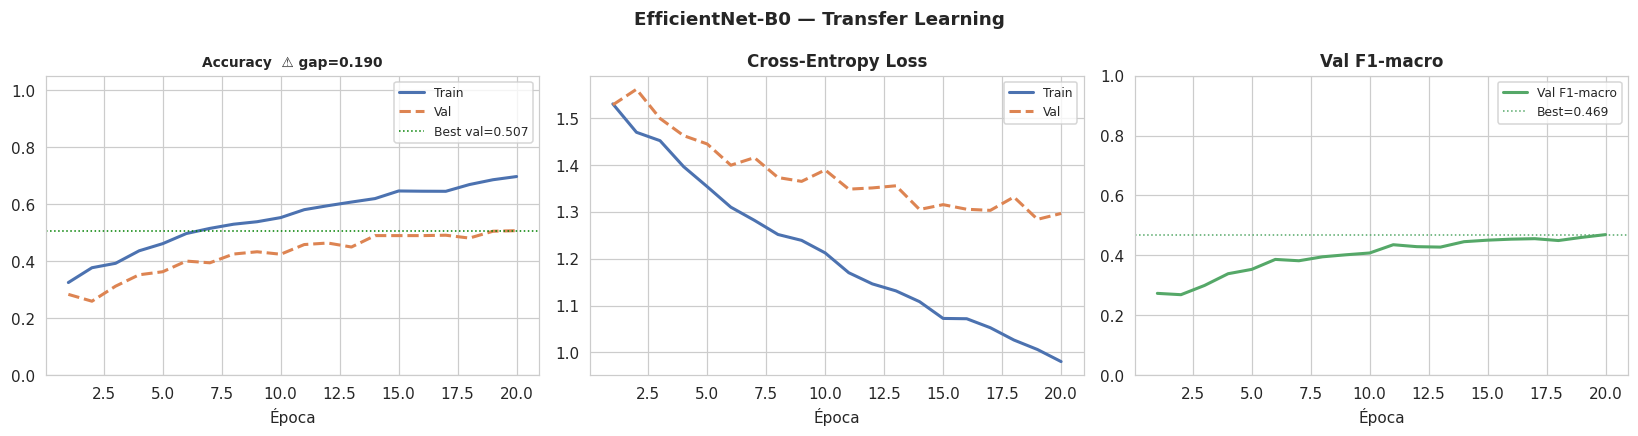

  Train acc: 0.6964  |  Val acc: 0.5067  |  Best val F1: 0.4694
EfficientNet-B0 → Val Accuracy: 0.5067  |  Val F1-macro: 0.4694


In [16]:
# ── EfficientNet-B0 ──────────────────────────────────────────────────────────
model_effnet, hist_effnet = train_transfer_learning('efficientnet_b0', n_epochs=20)
plot_curves(hist_effnet, 'EfficientNet-B0 — Transfer Learning', 'effnet')

_, acc_effnet, f1_effnet, _, _ = eval_epoch(
    model_effnet, dl_val, nn.CrossEntropyLoss(label_smoothing=0.1))
print(f'EfficientNet-B0 → Val Accuracy: {acc_effnet:.4f}  |  Val F1-macro: {f1_effnet:.4f}')


In [ ]:
# ── ResNet50 ─────────────────────────────────────────────────────────────────
model_resnet, hist_resnet = train_transfer_learning('resnet50', n_epochs=20)
plot_curves(hist_resnet, 'ResNet50 — Transfer Learning', 'resnet50')

_, acc_resnet, f1_resnet, _, _ = eval_epoch(
    model_resnet, dl_val, nn.CrossEntropyLoss(label_smoothing=0.1))
print(f'ResNet50 → Val Accuracy: {acc_resnet:.4f}  |  Val F1-macro: {f1_resnet:.4f}')


### 💡 Conclusión — Transfer Learning

**Señales de un entrenamiento sano:**
- En Fase 1 la val accuracy sube rápido (la cabeza aprende a aprovechar las features ImageNet)
- En Fase 2 hay una mejora adicional más gradual (el backbone se ajusta al dominio farmacéutico)
- El gap train/val debería ser menor que en la CNN scratch (el backbone preentrenado regulariza implícitamente)

**¿Por qué EfficientNet-B0 suele ganar a ResNet50 con pocos datos?**

EfficientNet escala ancho, profundidad y resolución de forma balanceada. En datasets pequeños-medianos, esta eficiencia se traduce en mejores representaciones con menos parámetros que sobreajustar. ResNet50 tiene 4× más parámetros, lo que puede ser una desventaja cuando los datos son escasos.


---
# BLOQUE 4 — Comparativa

## 10. Comparativa completa: Scratch vs Transfer Learning vs ML Clásico

In [ ]:
# Recopilar resultados de todos los modelos en val
criterion_eval = nn.CrossEntropyLoss()

resultados_dl = {}
for nombre, modelo in [('CNN Scratch', model_cnn),
                        ('EfficientNet-B0', model_effnet),
                        ('ResNet50', model_resnet)]:
    _, acc, f1, y_pred, y_true = eval_epoch(modelo, dl_val, criterion_eval)
    resultados_dl[nombre] = {'accuracy': acc, 'f1_macro': f1, 'y_pred': y_pred, 'y_true': y_true}

# Mejor modelo DL
mejor_nombre = max(resultados_dl, key=lambda k: resultados_dl[k]['f1_macro'])
mejor_modelo  = {'CNN Scratch': model_cnn,
                 'EfficientNet-B0': model_effnet,
                 'ResNet50': model_resnet}[mejor_nombre]

print('COMPARATIVA DE MODELOS DL — Val Set')
print('='*55)
for nombre, res in sorted(resultados_dl.items(), key=lambda x: -x[1]['f1_macro']):
    mark = ' ← MEJOR' if nombre == mejor_nombre else ''
    print(f'  {nombre:<20}  Acc={res["accuracy"]:.4f}  F1={res["f1_macro"]:.4f}{mark}')

# Añadir resultados de ML si están disponibles
ml_path = Path('output_ml/comparativa_modelos.csv')
if ml_path.exists():
    df_ml    = pd.read_csv(ml_path)
    ml_best  = df_ml.loc[df_ml['f1_macro'].idxmax()]
    print()
    print(f'  ML (mejor): {ml_best["modelo"]:<20}  Acc={ml_best["accuracy"]:.4f}  F1={ml_best["f1_macro"]:.4f}')
    mejora = resultados_dl[mejor_nombre]['f1_macro'] - ml_best['f1_macro']
    print(f'\n  Mejora DL sobre ML: +{mejora:.4f} en F1-macro  ({mejora/ml_best["f1_macro"]*100:+.1f}% relativo)')


In [ ]:
# Matrices de confusión de los 3 modelos DL
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
nombres_modelos = ['CNN Scratch', 'EfficientNet-B0', 'ResNet50']

for ax, nombre in zip(axes, nombres_modelos):
    res = resultados_dl[nombre]
    cm  = confusion_matrix(res['y_true'], res['y_pred'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[c[:8] for c in CLASES],
                yticklabels=[c[:8] for c in CLASES],
                ax=ax, cbar=False)
    color_t = '#C44E52' if nombre == mejor_nombre else 'black'
    prefix  = '🏆 ' if nombre == mejor_nombre else ''
    ax.set_title(f'{prefix}{nombre}\nAcc={res["accuracy"]:.3f}  F1={res["f1_macro"]:.3f}',
                 fontweight='bold', color=color_t, fontsize=9)
    ax.set_xlabel('Predicción', fontsize=8)
    ax.set_ylabel('Real', fontsize=8)
    ax.tick_params(axis='x', rotation=40, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.suptitle('Matrices de Confusión Normalizadas — Val Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dl_confusion_matrices.png', bbox_inches='tight')
plt.show()


### 💡 Conclusión — Comparativa

**Lectura de las matrices de confusión:**

La diagonal representa el recall por clase. Valores cercanos a 1.0 son buenos. Los errores fuera de la diagonal muestran qué clases se confunden entre sí.

Patrones típicos en este dominio:
- **"otros"** tiene los valores más bajos (es una clase comodín sin identidad visual propia)
- **Cardiovascular y Neurología** pueden confundirse (packaging azul-blanco similar)
- **Antiinfecciosos** suele distinguirse mejor (iconografía médica reconocible)

**El salto Scratch → Transfer Learning** debería ser visible en la diagonal: las clases que la CNN scratch no podía distinguir (recall bajo) mejoran notablemente con las representaciones ImageNet.


---
# BLOQUE 5 — Grad-CAM

## 11. Grad-CAM — ¿Dónde mira la red?

Grad-CAM (*Gradient-weighted Class Activation Mapping*) responde a la pregunta: **¿qué regiones de la imagen fueron determinantes para la predicción?**

Genera un mapa de calor superpuesto sobre la imagen original. Rojo/amarillo = alta influencia, azul = baja influencia.

**¿Para qué sirve en este proyecto?**
1. Verificar que el modelo mira el envase, no el fondo (si mira el fondo, hay sesgo en los datos)
2. Explicar predicciones a usuarios no técnicos
3. Identificar qué parte del packaging es discriminativa (¿el logo? ¿el color? ¿el texto?)


In [ ]:
class GradCAM:
    """Grad-CAM para EfficientNet-B0 y ResNet50."""
    def __init__(self, model, arch):
        self.model = model
        self.grads = None
        self.acts  = None
        self._register(arch)

    def _register(self, arch):
        if 'resnet' in arch:
            layer = self.model.layer4[-1].conv3
        else:   # efficientnet
            layer = self.model.features[-1][0]

        layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o.detach()))
        layer.register_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def compute(self, img_tensor):
        """img_tensor: (1, C, H, W). Devuelve (cam_array, pred_idx, probs)."""
        self.model.eval()
        logits = self.model(img_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()
        pred   = probs.argmax().item()
        self.model.zero_grad()
        logits[0, pred].backward()

        w   = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(1).squeeze(0)).cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, pred, probs.detach().cpu().numpy()

    def overlay(self, img_pil, cam, alpha=0.45):
        img_np  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE))).astype(np.uint8)
        cam_res = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        heat    = (mplcm.jet(cam_res)[:, :, :3] * 255).astype(np.uint8)
        return Image.fromarray(cv2.addWeighted(img_np, 1-alpha, heat, alpha, 0))


# Seleccionar el mejor modelo DL para Grad-CAM
arch_mejor = 'efficientnet_b0' if mejor_nombre == 'EfficientNet-B0' else 'resnet50'
gcam       = GradCAM(mejor_modelo, arch_mejor)

# Visualizar 2 imágenes por clase del val set
fig, axes = plt.subplots(N_CLS, 4, figsize=(16, 4 * N_CLS))

for row, cls in enumerate(CLASES):
    cls_idx = le.transform([cls])[0]
    sample  = dataset_val.df[dataset_val.df['clase'] == cls].head(2)

    for col_base, (_, srow) in enumerate(sample.iterrows()):
        if not Path(srow['image_path']).exists(): continue
        img_pil    = Image.open(srow['image_path']).convert('RGB')
        img_t      = transform_eval(img_pil).unsqueeze(0).to(DEVICE)
        cam, pred, probs = gcam.compute(img_t)
        overlay_img = gcam.overlay(img_pil, cam)
        is_correct  = (pred == cls_idx)

        ax_o = axes[row, col_base * 2]
        ax_o.imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        ax_o.axis('off')
        if col_base == 0:
            ax_o.set_title(f'{cls[:18]}', fontsize=8, fontweight='bold', color=PALETTE[cls])

        ax_c = axes[row, col_base * 2 + 1]
        ax_c.imshow(overlay_img)
        ax_c.axis('off')
        color = 'green' if is_correct else 'red'
        ax_c.set_title(f'Pred: {CLASES[pred][:12]}\n{probs[pred]:.1%}',
                       fontsize=7, color=color)

plt.suptitle(f'Grad-CAM — {mejor_nombre} — verde=correcto, rojo=error',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dl_gradcam.png', bbox_inches='tight')
plt.show()
print('✔ Grad-CAM guardado')


### 💡 Conclusión — Grad-CAM

**Qué indica cada patrón de activación:**

| Activaciones en... | Diagnóstico |
|-------------------|------------|
| El envase (frontal, logo, texto) | ✅ El modelo aprendió las características correctas |
| Solo el fondo | ⚠️ Shortcut learning — el modelo usa el contexto de la foto, no el medicamento |
| Área dispersa sin foco | ⚠️ Representación insuficiente — la clase es ambigua para el modelo |
| Borde de la imagen | ⚠️ Posible sesgo de encuadre en el dataset |

**Interpretación clínica**: en producción, el Grad-CAM acompañaría la predicción de la API para que el usuario (farmacéutico, paciente) pueda ver qué parte del envase determinó la clasificación. Un mapa de calor centrado en el logo del fabricante es mucho más confiable que uno centrado en el fondo blanco de la mesa.


---
# BLOQUE 6 — Evaluación Final y Exportación

## 12. Evaluación en test — una sola vez

El test set se toca **únicamente aquí**, con el modelo ya seleccionado. No hubo ninguna decisión de diseño basada en el test set (ni en este notebook ni en ningún otro).


In [ ]:
criterion_test = nn.CrossEntropyLoss()

test_loss, test_acc, y_pred_test, y_true_test = eval_epoch(mejor_modelo, dl_test, criterion_test)
f1_test = f1_score(y_true_test, y_pred_test, average='macro', zero_division=0)

print(f'EVALUACIÓN FINAL EN TEST — {mejor_nombre}')
print('='*60)
print(f'  Accuracy:  {test_acc:.4f}')
print(f'  F1-macro:  {f1_test:.4f}')
print()
print(classification_report(y_true_test, y_pred_test, target_names=le.classes_, digits=4))

# Val vs Test
val_acc_best = resultados_dl[mejor_nombre]['accuracy']
val_f1_best  = resultados_dl[mejor_nombre]['f1_macro']
print('─'*50)
print(f'  {"Métrica":<12} {"Val":>8} {"Test":>8} {"Δ":>8}')
print('─'*50)
print(f'  {"Accuracy":<12} {val_acc_best:>8.4f} {test_acc:>8.4f} {test_acc-val_acc_best:>+8.4f}')
print(f'  {"F1-macro":<12} {val_f1_best:>8.4f} {f1_test:>8.4f} {f1_test-val_f1_best:>+8.4f}')
print('─'*50)
delta = abs(test_acc - val_acc_best)
msg = ('✅ Generalización EXCELENTE' if delta < 0.02 else
       '✔  Generalización ACEPTABLE' if delta < 0.05 else
       '⚠  Posible sobreajuste al val')
print(f'  {msg}  (|Δ|={delta:.3f})')


In [ ]:
# Matriz de confusión test
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cm_t  = confusion_matrix(y_true_test, y_pred_test)
cm_tn = cm_t.astype(float) / cm_t.sum(axis=1, keepdims=True)

for ax, data, fmt, title in zip(
        axes,
        [cm_t, cm_tn],
        ['d', '.2f'],
        [f'TEST — absoluta\nAcc={test_acc:.3f}  F1={f1_test:.3f}',
         'TEST — normalizada (diagonal = recall)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, cbar=(fmt == '.2f'))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle(f'Evaluación Final en Test — {mejor_nombre}', fontsize=13,
             fontweight='bold', color='#C44E52')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dl_test_final.png', bbox_inches='tight')
plt.show()


### 💡 Conclusión — Evaluación Final

**El gap val → test es la métrica de honestidad metodológica más importante.** Un gap grande (>5 puntos de accuracy) indica que tomamos demasiadas decisiones mirando el val set, convirtiéndolo implícitamente en un segundo set de entrenamiento.

**Recall por clase** es lo que comunicaríamos a un regulador farmacéutico (AEMPS):
- Recall ≥ 0.75 en todas las clases → sistema apto para uso de apoyo
- Recall < 0.60 en alguna clase clínica principal → requiere mejora antes de despliegue


## 13. Exportación del modelo para la API

In [ ]:
# Guardar pesos del mejor modelo
arch_final = 'efficientnet_b0' if mejor_nombre == 'EfficientNet-B0' else 'resnet50'
torch.save(mejor_modelo.state_dict(), OUTPUT_DIR / f'best_model_{arch_final}.pth')

# LabelEncoder
joblib.dump(le, OUTPUT_DIR / 'label_encoder_dl.pkl')

# Metadatos completos para la API
metadata = {
    'arch':          arch_final,
    'num_classes':   N_CLS,
    'classes':       CLASES,
    'img_size':      IMG_SIZE,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std':  IMAGENET_STD,
    'val_accuracy':  float(val_acc_best),
    'val_f1_macro':  float(val_f1_best),
    'test_accuracy': float(test_acc),
    'test_f1_macro': float(f1_test),
    'trained_on':    time.strftime('%Y-%m-%d'),
}
with open(OUTPUT_DIR / 'model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('✔ Artefactos exportados en output_dl/:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name:<42} {p.stat().st_size/1024:.1f} KB')


In [ ]:
# Resumen ejecutivo final
print(f'''
╔══════════════════════════════════════════════════════════════════╗
║         RESUMEN — MÓDULO DEEP LEARNING                           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MODELOS ENTRENADOS                                              ║
║  ✔ CNN From Scratch (MedCNN, ~600K params)                      ║
║  ✔ EfficientNet-B0  (5.3M params, fine-tuning 2 fases)         ║
║  ✔ ResNet50         (25.6M params, fine-tuning 2 fases)         ║
║                                                                  ║
║  RESULTADOS EN VAL                                               ║
║  CNN Scratch  → F1 = {f1_cnn:.4f}                                 ║
║  EfficientNet → F1 = {f1_effnet:.4f}                                 ║
║  ResNet50     → F1 = {f1_resnet:.4f}                                 ║
║                                                                  ║
║  MEJOR MODELO (test): {mejor_nombre:<20}               ║
║  Test Accuracy = {test_acc:.4f}   Test F1-macro = {f1_test:.4f}          ║
║                                                                  ║
║  ARTEFACTOS EXPORTADOS                                           ║
║  ✔ best_model_{arch_final}.pth                              ║
║  ✔ label_encoder_dl.pkl                                         ║
║  ✔ model_metadata.json                                          ║
║                                                                  ║
║  SIGUIENTE PASO → Notebook 3: GenAI + API FastAPI               ║
╚══════════════════════════════════════════════════════════════════╝
''')
